In [3]:
# 1) Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Estandarización de variables numéricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import f1_score

In [4]:
df = pd.read_csv("accident (1).csv")
df

,age,gender,speed,helmet,seatbelt,survived
0,18,Female,20,No,Yes,1
1,28,Male,20,Yes,No,1
2,52,Male,20,Yes,No,1
3,52,Female,20,No,No,1
4,37,Female,21,No,No,1
...,...,...,...,...,...,...
195,50,Female,118,Yes,Yes,0
196,59,Female,118,Yes,No,0
197,67,Female,118,Yes,No,0
198,24,Female,119,Yes,Yes,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       200 non-null    int64
 1   gender    200 non-null    int64
 2   speed     200 non-null    int64
 3   helmet    200 non-null    int64
 4   seatbelt  200 non-null    int64
 5   survived  200 non-null    int64
dtypes: int64(6)
memory usage: 9.5 KB


In [7]:
is_null = df.isna().any() #ISNA -> VER SI NO ES NUM OSEA VALOR FALTANTE.
is_null[is_null]

,0


In [8]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

,0


In [5]:
df.gender = df.gender.map({"Male": 1, "Female":0 })
df.helmet = df.helmet.map({"Yes": 1, "No": 0})
df.seatbelt = df.seatbelt.map({"Yes": 1, "No": 0})

df

,age,gender,speed,helmet,seatbelt,survived
0,18,0,20,0,1,1
1,28,1,20,1,0,1
2,52,1,20,1,0,1
3,52,0,20,0,0,1
4,37,0,21,0,0,1
...,...,...,...,...,...,...
195,50,0,118,1,1,0
196,59,0,118,1,0,0
197,67,0,118,1,0,0
198,24,0,119,1,1,0


In [9]:
from sklearn.model_selection import train_test_split
x = df.drop("survived", axis=1)
y = df.survived

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=31)

Mejores parámetros SVM: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

SVM
Accuracy: 0.8
F1: 0.7894736842105263
ROC-AUC: 0.851010101010101
Matriz de confusión:
 [[17  5]
 [ 3 15]]
              precision    recall  f1-score   support

           0      0.850     0.773     0.810        22
           1      0.750     0.833     0.789        18

    accuracy                          0.800        40
   macro avg      0.800     0.803     0.799        40
weighted avg      0.805     0.800     0.801        40



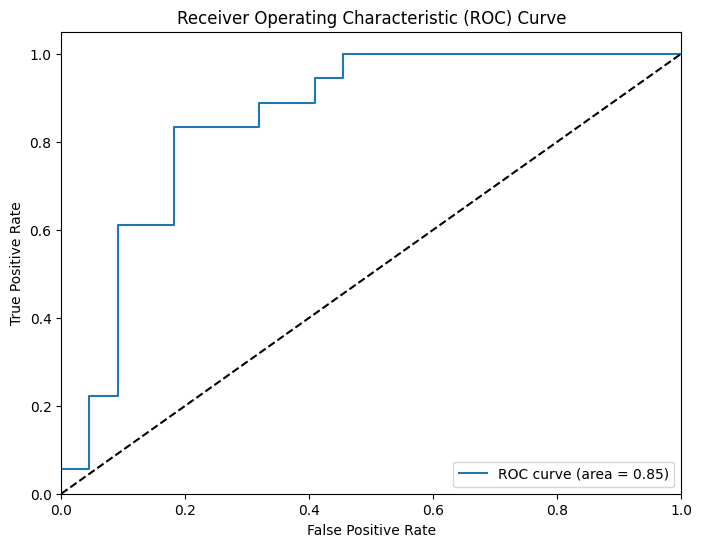

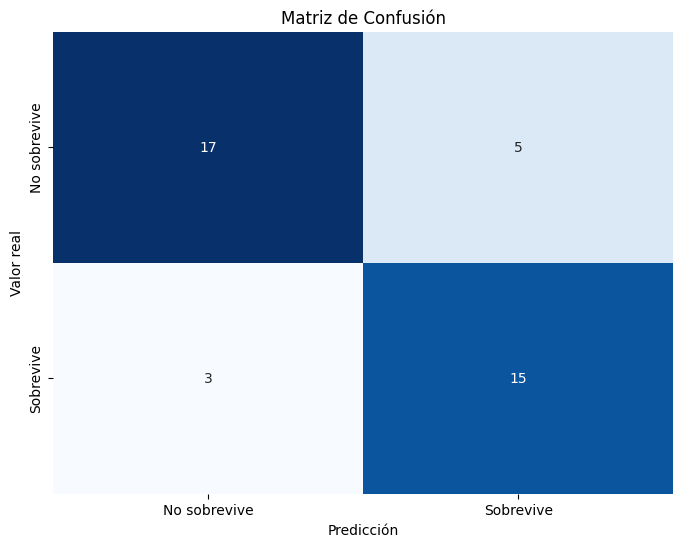


Caso específico:
Predicción: Sobrevive
Probabilidad estimada de supervivencia: 0.627


In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Variables predictoras y objetivo
X = df[['age', 'gender', 'speed', 'helmet', 'seatbelt']]
y = df['survived']

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ====== SVM con búsqueda de hiperparámetros ======
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True)) # Removed class_weight='balanced'
])

param_grid = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.1, 0.01]  # gamma solo aplica a RBF
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(pipe_svm, param_grid, scoring='f1', cv=cv, n_jobs=-1)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
print("Mejores parámetros SVM:", grid_svm.best_params_)


# ====== Evaluación ======
def eval_model(name, model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))

    # Graficar la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Graficar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No sobrevive', 'Sobrevive'],
                yticklabels=['No sobrevive', 'Sobrevive'])
    plt.xlabel('Predicción')
    plt.ylabel('Valor real')
    plt.title('Matriz de Confusión')
    plt.show()


eval_model("SVM", best_svm)

# ====== Predicción del caso específico ======
caso = pd.DataFrame([{
    'age': 30,
    'gender': 0,       # mujer
    'speed': 80,
    'helmet': 1,       # usa casco
    'seatbelt': 0      # no usa otro sistema
}])

pred = best_svm.predict(caso)[0]
proba = best_svm.predict_proba(caso)[0, 1]

print("\nCaso específico:")
print("Predicción:", "Sobrevive" if pred == 1 else "No sobrevive")
print(f"Probabilidad estimada de supervivencia: {proba:.3f}")